In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period

In [2]:
iyear = 1960
fyear = 2024
nx=10;ny=10
dom = 'GRp'

# SF & RF Data

In [3]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

# MONTHLY MEAN

In [4]:
TF = TF.groupby('time.month').mean('time', skipna=True)
TF = TF.mean(dim=['Y','X'], skipna=True)

SF = SF.groupby('time.month').mean('time', skipna=True)
SF = SF.mean(dim=['Y','X'], skipna=True)

RF = RF.groupby('time.month').mean('time', skipna=True)
RF = RF.mean(dim=['Y','X'], skipna=True)

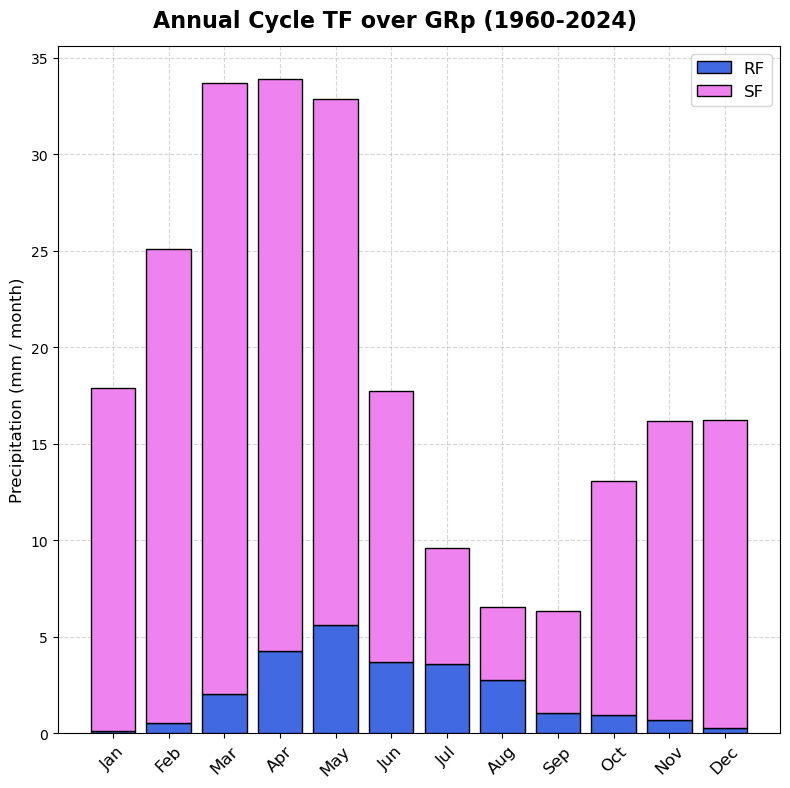

In [5]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

da_sf = SF
da_rf = RF

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle TF over {dom} ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Comparing with t2m

In [6]:
t2m = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TTZ_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TTZ'][:,0,:,:] # 0 = first pressure level at surface
t2m = t2m.rename({'TIME': 'time'})
t2m = t2m[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

In [7]:
t2m = t2m.groupby('time.month').mean('time', skipna=True)
t2m = t2m.mean(dim=['Y','X'], skipna=True)

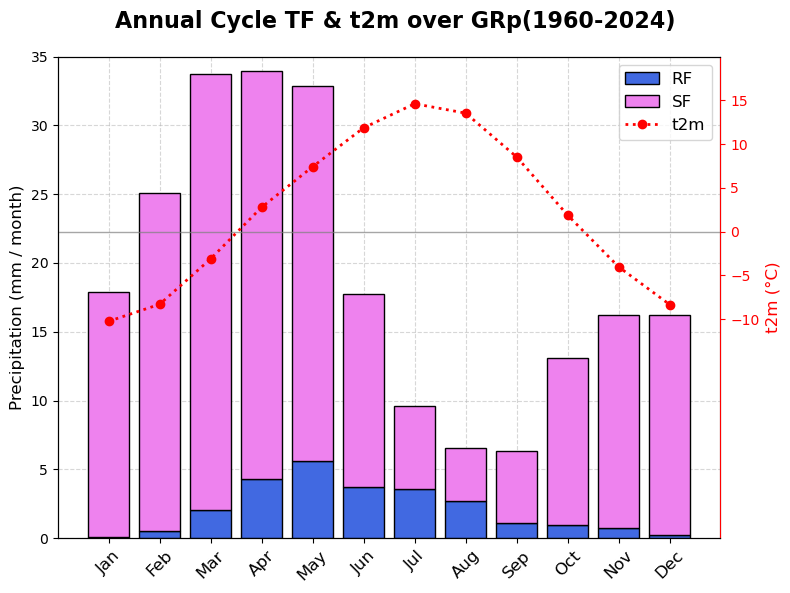

In [8]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,6))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

da_sf = SF
da_rf = RF
da_t2m = t2m

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

ax2.plot(
        da_t2m['month'], da_t2m.values,
        marker='o', linestyle=':',
        color='red',
        label=f't2m',
        linewidth=2
    )

ax2.axhline(y=0, color='grey', linestyle='-', linewidth=1, alpha = 0.7, zorder = 0)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax2.set_ylabel('t2m (°C)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# mettre la t2m au dessus de precipitation
ax.set_ylim(bottom=0, top=25) # axe gauche
ax2.set_ylim(bottom=-35, top=20) # axe droit

ticks = np.arange(-40, 20, 5)
ticks_filtered = ticks[(ticks >= -10) & (ticks <= 20)]
ax2.set_yticks(ticks_filtered)

ticks = np.arange(0, 40, 5)
ticks_filtered = ticks[(ticks >= 0) & (ticks <= 40)]
ax.set_yticks(ticks_filtered)

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=12)

fig.suptitle(f'Annual Cycle TF & t2m over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Only on Glaciers

In [17]:
# ICE data
ds_pamir=xr.open_dataset('/home/santolam/NST.2014.01.01.00.GRi.nc')#['SH']#[nx:-nx,ny:-ny]
dsICE_pamir=ds_pamir['ICE'][nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON[nx:-nx,ny:-ny],ds_pamir.LAT[nx:-nx,ny:-ny]

In [18]:
# Distribution des pixels selon l'altitude
dsSH_pamir=ds_pamir['SH'][nx:-nx,ny:-ny]
elev_bands = np.arange(0, 8001, 250)
elev_areas = dsSH_pamir.groupby_bins(dsSH_pamir, bins = elev_bands).count()
elev_areas = elev_areas * 49 # Convert to km2

# Distribution de l'altitude sur GRp

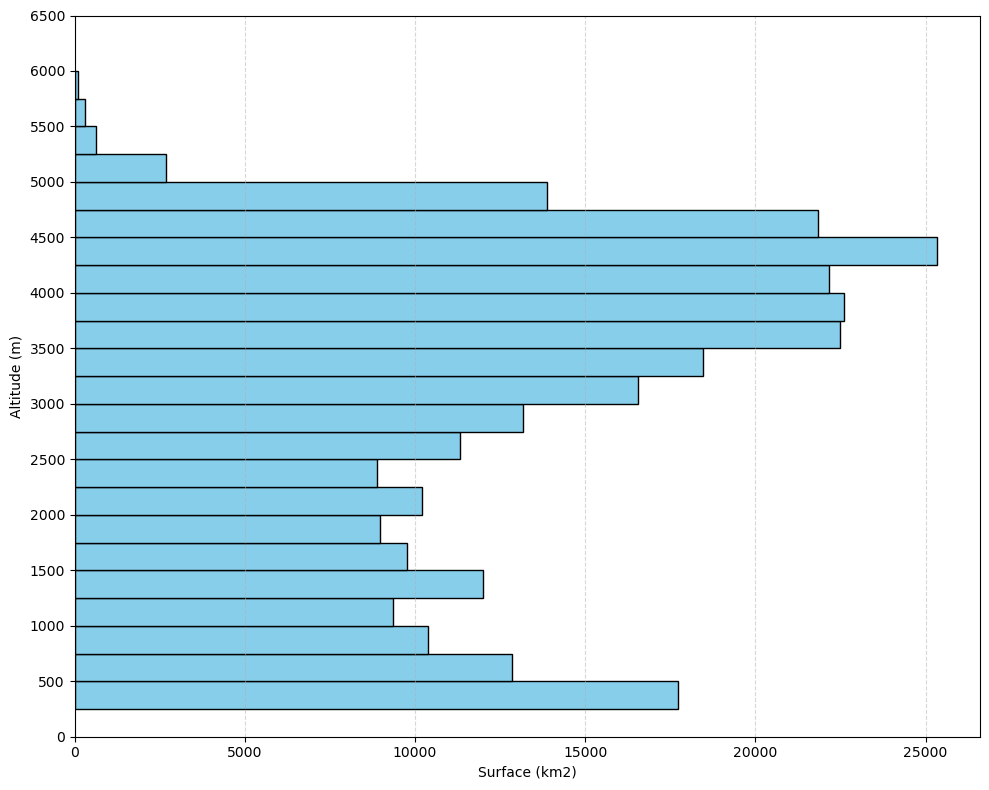

In [19]:
# Récupération des bords inférieurs des bandes pour l'axe Y
y_bottoms = [interval.left for interval in elev_areas.SH_bins.values]
x_values = elev_areas.values

# Tracé du bar plot
plt.figure(figsize=(10, 8))

# align='edge' permet de caler le bas de la barre sur la valeur de y_bottoms
plt.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black')

# 5. Réglage des graduations pour voir les paliers de 250m
plt.yticks(np.arange(0, 8001, 500)) # Une graduation tous les 500m pour la lisibilité
plt.ylim(0, 6500)

plt.xlabel("Surface (km2)")
plt.ylabel("Altitude (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Distribution des glaciers sur GRp

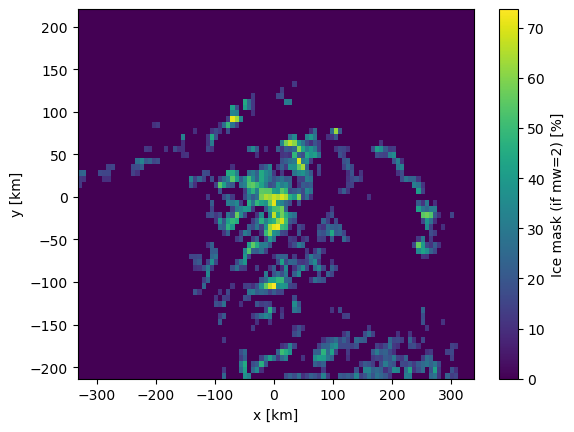

In [20]:
dsICE_pamir.plot()

In [22]:
dsSH_pamir = dsSH_pamir.rename({'x': 'X', 'y': 'Y'})
dsICE_pamir = dsICE_pamir.rename({'x': 'X', 'y': 'Y'})

#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
dsICE_pamir = dsICE_pamir.assign_coords({
    "X": dsSH_pamir.X,
    "Y": dsSH_pamir.Y
})

ICE_areas = (dsICE_pamir / 100) * 49 # Surface de glace réelle par pixel
elev_bands = np.arange(0, 8001, 250)
ICE_areas = ICE_areas.groupby_bins(dsSH_pamir, bins = elev_bands).sum() # Surface totale de glace réelle par bande d'élévation

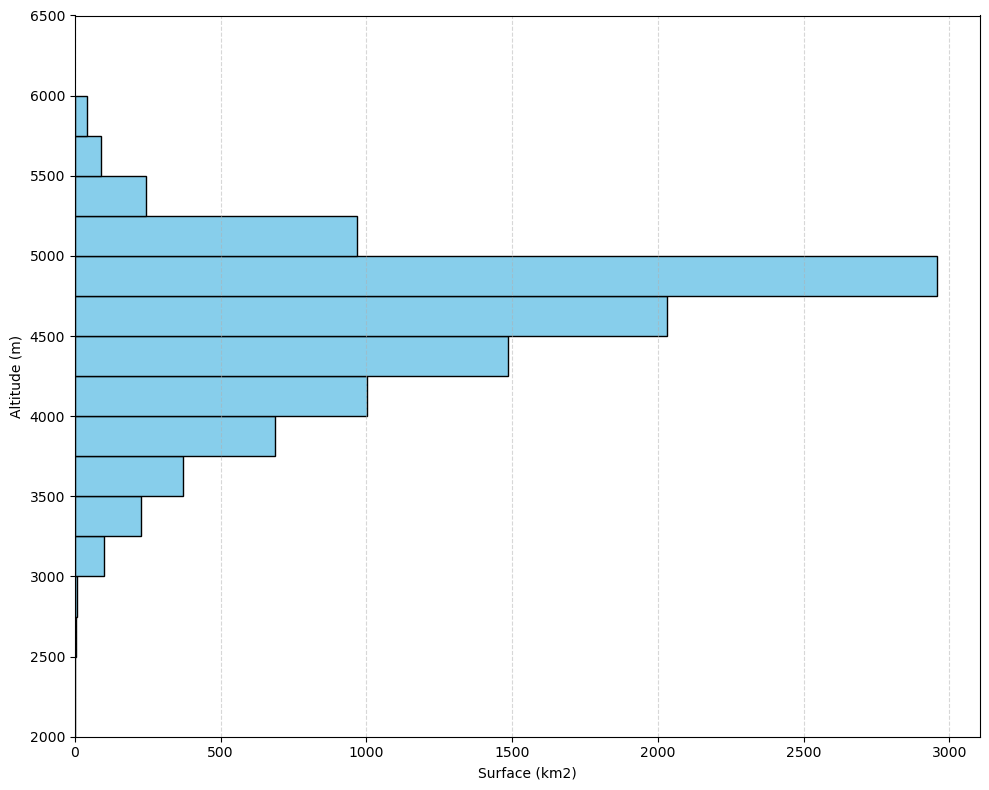

In [23]:
# Récupération des bords inférieurs des bandes pour l'axe Y
y_bottoms = [interval.left for interval in ICE_areas.SH_bins.values]
x_values = ICE_areas.values

# Tracé du bar plot
plt.figure(figsize=(10, 8))

# align='edge' permet de caler le bas de la barre sur la valeur de y_bottoms
plt.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black')

# 5. Réglage des graduations pour voir les paliers de 250m
plt.yticks(np.arange(0, 8001, 500)) # Une graduation tous les 500m pour la lisibilité
plt.ylim(2000, 6500)

plt.xlabel("Surface (km2)")
plt.ylabel("Altitude (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
ICE_tot = ICE_areas.sum()
print(ICE_tot)

<xarray.DataArray 'ICE' ()> Size: 4B
array(10218.177, dtype=float32)


# Annual Cycle on glacierized areas

In [29]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

In [30]:
TF = TF.groupby('time.month').mean('time', skipna=True)
TF = (TF * dsICE_pamir)
TF = TF.sum(dim=['Y','X'], skipna=True) / ICE_tot

SF = SF.groupby('time.month').mean('time', skipna=True)
SF = (SF * dsICE_pamir)
SF = SF.sum(dim=['Y','X'], skipna=True) / ICE_tot

RF = RF.groupby('time.month').mean('time', skipna=True)
RF = (RF * dsICE_pamir)
RF = RF.sum(dim=['Y','X'], skipna=True) / ICE_tot

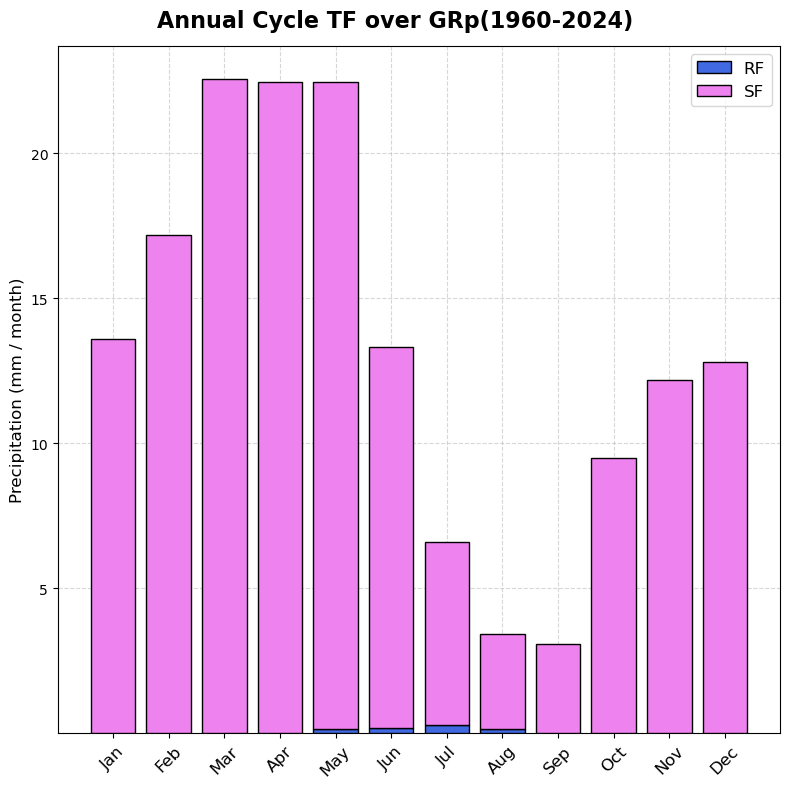

In [31]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

da_sf = SF
da_rf = RF

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle TF over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# FLH in GRp glacierized

In [32]:
FLH = pd.read_csv(f'/bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_1960-2024_GRp.csv', parse_dates=["time"])
FLH = FLH.set_index('time')

In [33]:
# Monthly mean over study period for FLH computed by MAR 
FLH_monthly_mean = FLH.groupby(FLH.index.month)['FLH'].mean().reset_index()
FLH_monthly_mean.columns = ['Month', 'FLH']

In [34]:
FLH_monthly_mean

,Month,FLH
0,1,NaN
1,2,NaN
2,3,2824.507738
3,4,3258.800096
4,5,3825.643930
5,6,4414.620604
6,7,4908.093185
7,8,4911.405616
8,9,4255.877187
9,10,3302.428198


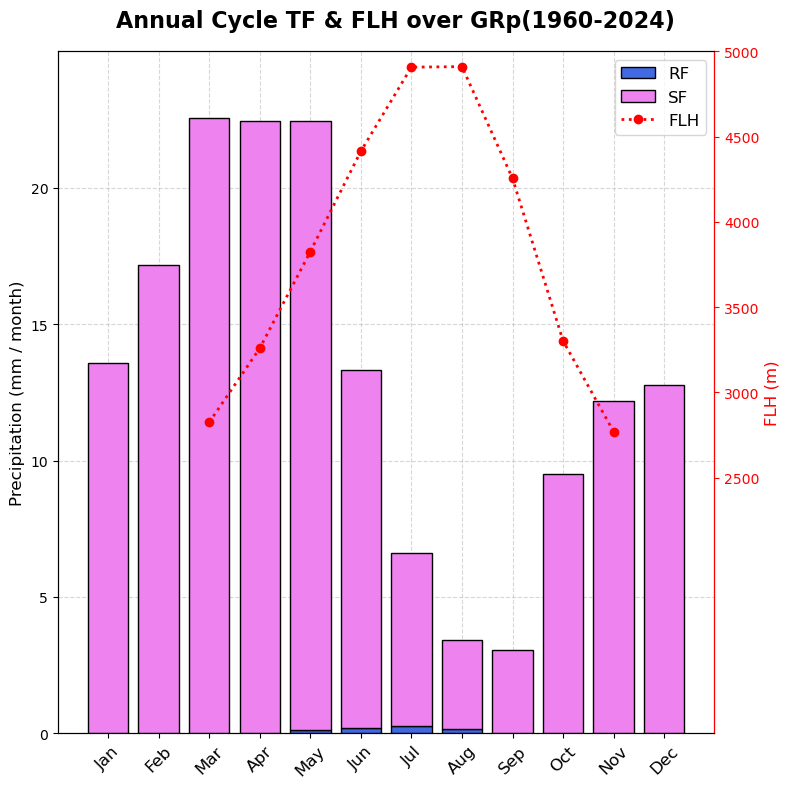

In [35]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

da_sf = SF
da_rf = RF
da_flh = FLH_monthly_mean

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

ax2.plot(
    	da_flh['Month'], da_flh['FLH'].values,
    	marker='o', linestyle=':',
    	color='red',
    	label=f'FLH',
    	linewidth=2
	)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax2.set_ylabel('FLH (m)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# mettre la t2m au dessus de precipitation
ax.set_ylim(bottom=0, top=25) # axe gauche
ax2.set_ylim(bottom=1000, top=5000) # axe droit

ticks = np.arange(1000, 5001, 500)
ticks_filtered = ticks[(ticks >= 2500) & (ticks <= 5000)]
ax2.set_yticks(ticks_filtered)

ticks = np.arange(0, 25, 5)
ticks_filtered = ticks[(ticks >= 0) & (ticks <= 25)]
ax.set_yticks(ticks_filtered)

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=12)

fig.suptitle(f'Annual Cycle TF & FLH over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

Horizontal lines represent the FLH value for each month of the year


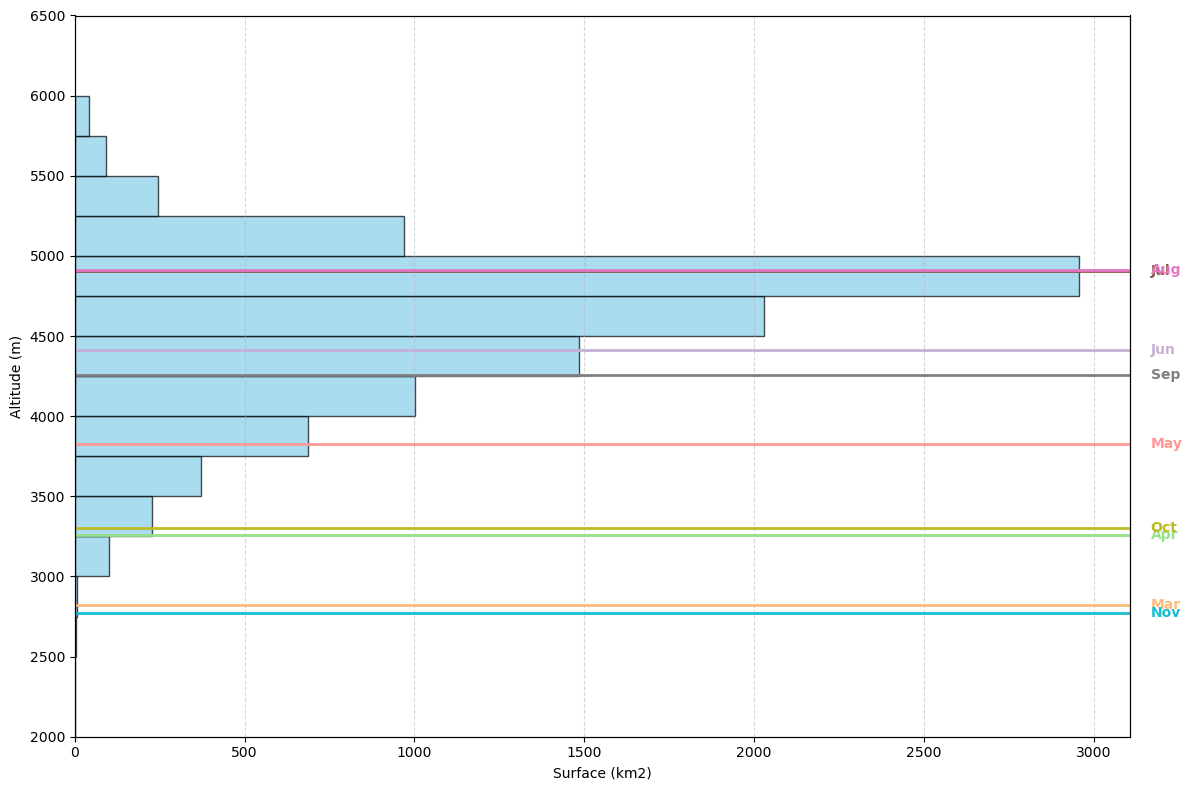

In [36]:
print('Horizontal lines represent the FLH value for each month of the year')

fig, ax1 = plt.subplots(figsize=(12, 8))

# Tracé du bar plot sur l'axe principal (gauche)
ax1.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black', alpha=0.7)

# Réglages axe gauche
ax1.set_yticks(np.arange(0, 8001, 500))
ax1.set_ylim(2000, 6500)
ax1.set_xlabel("Surface (km2)")
ax1.set_ylabel("Altitude (m)")
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Création de l'axe secondaire (droite)
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim()) # On aligne les limites verticales

# Ajout des hlines et des labels de mois
# On définit une palette de couleurs pour différencier les mois
colors = plt.colormaps['tab20'].resampled(12)

# Liste des noms de mois pour l'affichage
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# On itère sur les lignes de votre tableau de résultats
# (tab_mensuel doit avoir les colonnes 'Mois' [1-12] et 'FLH')
for i, row in FLH_monthly_mean.iterrows():
    val_flh = row['FLH']
    month_idx = int(row['Month']) - 1 # Pour l'index de 0 à 11
    
    if not np.isnan(val_flh):
        color = colors(month_idx)
        
        # Tracer la ligne horizontale
        ax1.axhline(y=val_flh, color=color, linestyle='-', linewidth=2, label=month_names[month_idx])
        
        # Ajouter le nom du mois sur l'axe de droite
        # On place le texte à la hauteur de la ligne
        ax2.text(1.02, val_flh, month_names[month_idx], 
                 transform=ax2.get_yaxis_transform(), 
                 color=color, fontweight='bold', va='center')

# On cache les graduations par défaut de l'axe de droite pour ne pas surcharger
ax2.set_yticks([]) 

plt.tight_layout()
plt.show()